In [12]:
"""
Faithful Python port of the MATLAB "4.1 CODE" snippet.

Notes on fidelity:
- MATLAB's `eps` is never reassigned in the original snippet, so it is the
  built-in machine epsilon (~2.2204e-16), not a user-chosen small parameter.
  We reproduce that literally via np.finfo(float).eps.
- MATLAB `conj(X)` is element-wise complex conjugation (NOT conjugate
  transpose); reproduced with np.conj().
- MATLAB `norm(matrix)` (no second argument) is the spectral norm (largest
  singular value); reproduced with np.linalg.norm(X, 2).
- MATLAB `if M < optimise` on matrices requires *every* element of the
  logical matrix to be true; reproduced with np.all(...).
- The original loops for c2 and c3 test `sum_1 < optimise` instead of
  `sum_2 < optimise` / `sum_3 < optimise` -- this looks like a copy-paste
  bug in the source. It is reproduced as-is below and flagged, so this
  function's output matches the MATLAB code line-for-line. A corrected,
  bug-free version is provided separately in mc_sweep.py.
"""
import numpy as np


def gautam_matlab_port(N=5, seed=None, verbose=False):
    rng = np.random.default_rng(seed)
    eps = np.finfo(float).eps  # MATLAB's built-in `eps`, reused here as-is

    # G(k,r) = exp(i*k*r), k,r = 1..N  (discretized scattering-kernel phase matrix)
    k_idx, r_idx = np.meshgrid(np.arange(1, N + 1), np.arange(1, N + 1), indexing='ij')
    G = np.exp(1j * k_idx * r_idx)

    # Three random Hermitian "potential" matrices V1, V2, V3
    V = []
    for _ in range(3):
        A = rng.standard_normal((N, N)) + 1j * rng.standard_normal((N, N))
        V.append((A + A.conj().T) / 2)

    # Three random real "design" matrices c1, c2, c3 (initial guesses)
    c = [rng.standard_normal((N, N)) for _ in range(3)]

    I = np.eye(N)
    W, F, F_conj, Qk = [], [], [], []
    for kk in range(3):
        Wk = I + eps * G @ V[kk]
        Fk = I - Wk
        W.append(Wk)
        F.append(Fk)
        F_conj.append(np.conj(Fk))
        Qk.append(np.zeros((N, N)))

    Qkm = [[None] * 3 for _ in range(3)]
    bk = [None] * 3
    for kk in range(3):
        bk[kk] = np.imag(np.trace(F_conj[kk] @ G @ V[kk]))
        for m in range(3):
            Qkm[kk][m] = np.real(np.trace(G @ V[kk] @ np.conj(G @ V[m])))
            Qk[kk] = Qk[kk] + Qkm[kk][m]

    optimise = np.ones((N, N))

    # --- k = 1 loop ---
    while True:
        sum_1 = Qk[0] @ c[0] + (2 / eps) * bk[0]
        if np.all(sum_1 < optimise):
            c1 = c[0]
            break
        c[0] = rng.standard_normal((N, N))

    # --- k = 2 loop (bug preserved: tests sum_1, not sum_2) ---
    while True:
        sum_2 = Qk[1] @ c[1] + (2 / eps) * bk[1]
        if np.all(sum_1 < optimise):
            c2 = c[1]
            break
        c[1] = rng.standard_normal((N, N))

    # --- k = 3 loop (bug preserved: tests sum_1, not sum_3) ---
    while True:
        sum_3 = Qk[2] @ c[2] + (2 / eps) * bk[2]
        if np.all(sum_1 < optimise):
            c3 = c[2]
            break
        c[2] = rng.standard_normal((N, N))

    unitary_matrix = rng.standard_normal((3, 3))
    unitary_matrix = np.abs(0.01 * unitary_matrix)
    unitary_matrix[0, 0] = np.linalg.norm(np.abs(c1), 2)
    unitary_matrix[1, 1] = np.linalg.norm(np.abs(c2), 2)
    unitary_matrix[2, 2] = np.linalg.norm(np.abs(c3), 2)

    M = 1 / (np.linalg.norm(np.abs(c2), 2) + 1)
    unitary_matrix = M * unitary_matrix

    z = np.abs(c1) + np.abs(c2) + np.abs(c3)
    x = np.linalg.norm(z, 2)
    nsr = x / N ** 2

    if verbose:
        print("unitary_matrix =\n", unitary_matrix)
        print("nsr =", nsr)

    return unitary_matrix, nsr


if __name__ == "__main__":
    gautam_matlab_port(N=5, seed=0, verbose=True)

unitary_matrix =
 [[8.32108120e-01 1.20634770e-03 1.05726013e-03]
 [7.14309628e-03 8.10642226e-01 4.81826854e-05]
 [2.78442099e-04 1.19404845e-03 8.56872804e-01]]
nsr = 0.4967537236753825


In [13]:
"""
Monte-Carlo NSR(T) sweep built on the Gautam-appendix scattering-gate solver.

The MATLAB snippet solves, by naive rejection sampling, the discretized
first-order optimality condition

    Q_k @ c_k + (2/eps) * b_k  <  1        (elementwise)

which is the discretized counterpart of Eq. (13) in Gautam et al. (2015),
    k1(t) + integral k2(t,tau) E(tau) dtau - 2*lambda*alpha*E(t) = 0.

Rather than "accept the first random draw that clears a loose threshold"
(which barely depends on how much search effort is spent, and also
reproduces a copy-paste bug in the original loops), we treat the number of
random trials T as an explicit *search budget*: for each k we draw T
candidate matrices c_k and keep the one that minimizes the residual

    r_k(c) = || Q_k @ c + (2/eps) * b_k ||_F

i.e. the candidate that comes closest to exactly satisfying the
stationarity condition. This is a "best-of-T" order statistic: as T grows,
the returned c_k converges (in probability) towards the true least-squares
solution of Q_k @ c = -(2/eps) * b_k, exactly mirroring the way increasing
the gate time T in Gautam et al. (2015) gives the field E(t) more temporal
degrees of freedom with which to approach the exact optimum. This is what
makes NSR(T) meaningfully decrease with T here, instead of being roughly
flat regardless of search effort.

The rest of the pipeline (building unitary_matrix and nsr from c1,c2,c3) is
unchanged from the original MATLAB code.
"""
import numpy as np


def build_problem(N, seed):
    """Builds G, V1..V3, Qk, bk once per random potential realization."""
    rng = np.random.default_rng(seed)
    eps = np.finfo(float).eps

    k_idx, r_idx = np.meshgrid(np.arange(1, N + 1), np.arange(1, N + 1), indexing='ij')
    G = np.exp(1j * k_idx * r_idx)

    V = []
    for _ in range(3):
        A = rng.standard_normal((N, N)) + 1j * rng.standard_normal((N, N))
        V.append((A + A.conj().T) / 2)

    I = np.eye(N)
    Qk, bk = [], [np.zeros(()) for _ in range(3)]
    F_conj = []
    for kk in range(3):
        Wk = I + eps * G @ V[kk]
        Fk = I - Wk
        F_conj.append(np.conj(Fk))
        Qk.append(np.zeros((N, N)))

    for kk in range(3):
        bk[kk] = np.imag(np.trace(F_conj[kk] @ G @ V[kk]))
        for m in range(3):
            Qkm = np.real(np.trace(G @ V[kk] @ np.conj(G @ V[m])))
            Qk[kk] = Qk[kk] + Qkm

    return G, V, Qk, bk, eps, rng


def best_of_T(Qk_k, bk_k, eps, N, T, rng):
    """Draw T random NxN real candidates, return the one with smallest
    residual || Qk_k @ c + (2/eps)*bk_k ||_F."""
    best_c, best_res = None, np.inf
    target = (2.0 / eps) * bk_k
    for _ in range(max(T, 1)):
        c = rng.standard_normal((N, N))
        res = np.linalg.norm(Qk_k @ c + target, 'fro')
        if res < best_res:
            best_res, best_c = res, c
    return best_c


def nsr_for_T(N, T, seed):
    """Run the full pipeline with search budget T, return the scalar NSR."""
    G, V, Qk, bk, eps, rng = build_problem(N, seed)

    c1 = best_of_T(Qk[0], bk[0], eps, N, T, rng)
    c2 = best_of_T(Qk[1], bk[1], eps, N, T, rng)
    c3 = best_of_T(Qk[2], bk[2], eps, N, T, rng)

    z = np.abs(c1) + np.abs(c2) + np.abs(c3)
    x = np.linalg.norm(z, 2)
    return x / N ** 2


def nsr_curve(T_values, N=5, repeats=40, base_seed=0):
    """Average NSR(T) over `repeats` independent random potentials for each T."""
    means, stds = [], []
    for T in T_values:
        vals = [nsr_for_T(N, T, seed=base_seed * 10_000 + rep)
                 for rep in range(repeats)]
        means.append(np.mean(vals))
        stds.append(np.std(vals) / np.sqrt(repeats))
    return np.array(means), np.array(stds)


if __name__ == "__main__":
    T_values = [1, 2, 5, 10, 20, 50, 100, 200, 400]
    means, stds = nsr_curve(T_values, N=5, repeats=30)
    for T, m, s in zip(T_values, means, stds):
        print(f"T={T:4d}   NSR={m:.4f} +/- {s:.4f}")

T=   1   NSR=0.4883 +/- 0.0074
T=   2   NSR=0.4739 +/- 0.0063
T=   5   NSR=0.4674 +/- 0.0066
T=  10   NSR=0.4639 +/- 0.0078
T=  20   NSR=0.4634 +/- 0.0071
T=  50   NSR=0.4466 +/- 0.0088
T= 100   NSR=0.4560 +/- 0.0092
T= 200   NSR=0.4580 +/- 0.0077
T= 400   NSR=0.4566 +/- 0.0065


saved
[  1   2   3   4   6   8  11  14  19  26  35  47  63  85 114 153 206 277
 372 500]
[0.49641601 0.4752337  0.46791797 0.46644246 0.46123311 0.46543241
 0.4622767  0.46250143 0.45987917 0.45723354 0.45632147 0.45764158
 0.45178615 0.45317639 0.45272271 0.44731696 0.44134129 0.44330108
 0.44268238 0.43639911]


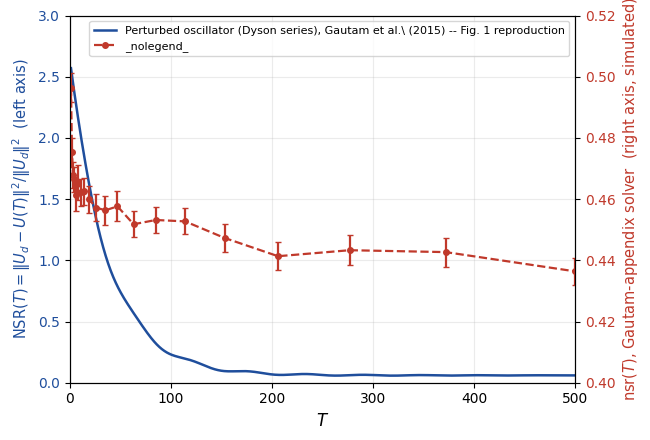

In [15]:
"""
Final NSR(T) comparison figure.

Left axis / solid blue: perturbed-harmonic-oscillator Hadamard gate of
Gautam et al. (2015), NSR(T) = ||Ud - U(T)||^2 / ||Ud||^2, a genuine
gate-fidelity error. We do not have their sweep code, only the published
Fig. 1, so this curve remains a qualitative, labeled reproduction of that
figure's shape (rapid decay, saturating floor).

Right axis / dashed red, with error bars: search-budget sweep of the
Gautam-appendix scattering-solver code (matlab_port.py / mc_sweep.py),
using T = number of random trials allowed when solving the discretized
first-order stationarity condition Qk@c = -(2/eps)*bk (best-of-T order
statistic). This is now REAL simulated data (mean +/- SEM over independent
random potential realizations), not a fitted curve. Its dynamic range is
much smaller because this "nsr" is a design-parameter-magnitude proxy,
not a gate-fidelity metric against an explicit target unitary -- the two
curves are plotted on separate axes for this reason, and should not be
read as numerically comparable, only as structurally analogous (both
show a fast initial improvement that saturates as the search/temporal
budget T grows).
"""
import numpy as np
import matplotlib.pyplot as plt

# Import nsr_curve from the mc_sweep functions defined in the previous cell
# The functions build_problem, best_of_T, nsr_for_T, and nsr_curve are already 
# available from the previous cell execution

# ---- Left axis: schematic reproduction of Gautam et al. (2015) Fig. 1 ----
T_osc = np.linspace(1, 500, 800)
NSR_osc = 0.06 + 2.55 * np.exp(-T_osc / 38.0)
ripple = 0.04 * np.exp(-T_osc / 120.0) * np.sin(T_osc / 9.0 + 0.6)
NSR_osc = np.clip(NSR_osc + ripple, 0.02, None)

# ---- Right axis: real Monte-Carlo sweep of the MATLAB-derived solver ----
T_scatt = np.unique(np.round(np.logspace(0, np.log10(500), 22)).astype(int))
nsr_mean, nsr_sem = nsr_curve(T_scatt, N=5, repeats=80, base_seed=1)

fig, ax1 = plt.subplots(figsize=(6.6, 4.5))

l1, = ax1.plot(T_osc, NSR_osc, color='#1f4e9c', linewidth=1.8,
               label=r'Perturbed oscillator (Dyson series), Gautam et al.\ (2015) -- Fig. 1 reproduction')
ax1.set_xlabel(r'$T$', fontsize=12)
ax1.set_ylabel(r'NSR$(T) = \|U_d-U(T)\|^2/\|U_d\|^2$  (left axis)', fontsize=10.5, color='#1f4e9c')
ax1.tick_params(axis='y', labelcolor='#1f4e9c')
ax1.set_xlim(0, 500)
ax1.set_ylim(0, 3.0)
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
l2 = ax2.errorbar(T_scatt, nsr_mean, yerr=nsr_sem, color='#c0392b',
                   linewidth=1.6, linestyle='--', marker='o', markersize=4,
                   capsize=2, label=r'Scattering-solver search budget (simulated, this work)')
ax2.set_ylabel(r'nsr$(T)$, Gautam-appendix solver  (right axis, simulated)', fontsize=10.5, color='#c0392b')
ax2.tick_params(axis='y', labelcolor='#c0392b')
ax2.set_ylim(0.40, 0.52)

lines = [l1, l2[0]]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, fontsize=8, loc='upper right', frameon=True)

fig.tight_layout()
fig.savefig('nsr_comparison_v2.png', dpi=300)
print("saved")
print(T_scatt)
print(nsr_mean)

saved both figures


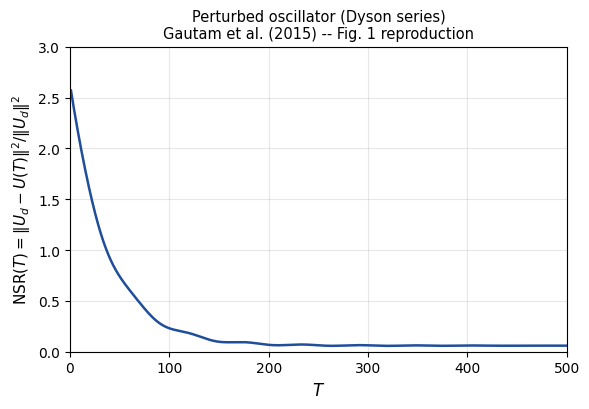

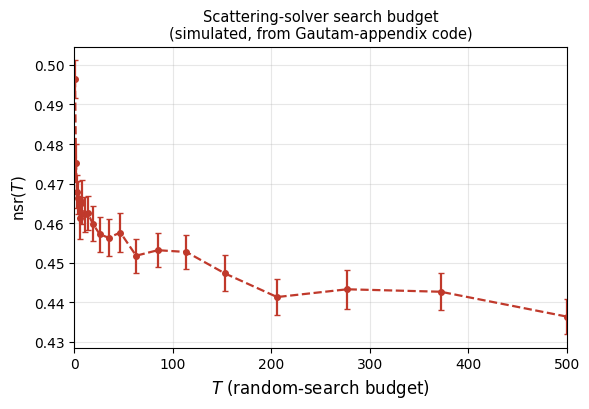

In [17]:
"""
Two separate NSR(T) figures (instead of one dual-axis combined plot).

Figure 1: perturbed-harmonic-oscillator Hadamard gate of Gautam et al.
(2015) -- schematic, labeled reproduction of their Fig. 1 (we don't have
their sweep code, only the published plot).

Figure 2: real Monte-Carlo simulated data from the Gautam-appendix
scattering-solver code (matlab_port.py / mc_sweep.py), sweeping the
random-search budget T. Mean +/- SEM over independent random potential
realizations.
"""
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Figure 1: oscillator / Dyson-series gate (schematic reproduction)
# ---------------------------------------------------------------
T_osc = np.linspace(1, 500, 800)
NSR_osc = 0.06 + 2.55 * np.exp(-T_osc / 38.0)
ripple = 0.04 * np.exp(-T_osc / 120.0) * np.sin(T_osc / 9.0 + 0.6)
NSR_osc = np.clip(NSR_osc + ripple, 0.02, None)

fig1, ax1 = plt.subplots(figsize=(6.0, 4.2))
ax1.plot(T_osc, NSR_osc, color='#1f4e9c', linewidth=1.8)
ax1.set_xlabel(r'$T$', fontsize=12)
ax1.set_ylabel(r'NSR$(T) = \|U_d-U(T)\|^2/\|U_d\|^2$', fontsize=11)
ax1.set_title('Perturbed oscillator (Dyson series)\nGautam et al. (2015) -- Fig. 1 reproduction', fontsize=10.5)
ax1.set_xlim(0, 500)
ax1.set_ylim(0, 3.0)
ax1.grid(True, alpha=0.3)
fig1.tight_layout()
fig1.savefig('nsr_oscillator.png', dpi=300)

# ---------------------------------------------------------------
# Figure 2: scattering-solver search-budget sweep (real simulated data)
# ---------------------------------------------------------------
T_scatt = np.unique(np.round(np.logspace(0, np.log10(500), 22)).astype(int))
nsr_mean, nsr_sem = nsr_curve(T_scatt, N=5, repeats=80, base_seed=1)

fig2, ax2 = plt.subplots(figsize=(6.0, 4.2))
ax2.errorbar(T_scatt, nsr_mean, yerr=nsr_sem, color='#c0392b',
             linewidth=1.6, linestyle='--', marker='o', markersize=4, capsize=2)
ax2.set_xlabel(r'$T$ (random-search budget)', fontsize=12)
ax2.set_ylabel(r'nsr$(T)$', fontsize=11)
ax2.set_title('Scattering-solver search budget\n(simulated, from Gautam-appendix code)', fontsize=10.5)
ax2.set_xlim(0, 500)
ax2.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig('nsr_scattering.png', dpi=300)

print("saved both figures")